In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('PHY-231_ Midterm Project  - mxmh_survey_results.csv')

In [4]:
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [5]:
# Check missing values in key columns we need to answer this question
df[['Music effects', 'Anxiety', 'Depression']].isnull().sum()

Music effects    8
Anxiety          0
Depression       0
dtype: int64

In [6]:
# we need to drop rows where Music effects, Anxiety, or Depression are missing
df_clean = df.dropna(subset=['Music effects', 'Anxiety', 'Depression'])


print("Original data:", df.shape)
print("After dropping missing:", df_clean.shape)

Original data: (736, 33)
After dropping missing: (728, 33)


In [7]:
# Convert to numeric (coerce errors into NaN)
df_clean['Anxiety'] = pd.to_numeric(df_clean['Anxiety'], errors='coerce')
df_clean['Depression'] = pd.to_numeric(df_clean['Depression'], errors='coerce')

# Drop any rows that became NaN after conversion
df_clean = df_clean.dropna(subset=['Anxiety', 'Depression'])


/tmp/ipykernel_151/396042395.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Anxiety'] = pd.to_numeric(df_clean['Anxiety'], errors='coerce')
/tmp/ipykernel_151/396042395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Depression'] = pd.to_numeric(df_clean['Depression'], errors='coerce')


In [8]:
# Clean text column
df_clean['Music effects'] = df_clean['Music effects'].str.strip()

# Check unique categories
df_clean['Music effects'].value_counts()


Music effects
Improve      542
No effect    169
Worsen        17
Name: count, dtype: int64

In [9]:

df_clean['Music effects'] = df_clean['Music effects'].str.title()

In [10]:
print("Anxiety range:", df_clean['Anxiety'].min(), "-", df_clean['Anxiety'].max())
print("Depression range:", df_clean['Depression'].min(), "-", df_clean['Depression'].max())


Anxiety range: 0.0 - 10.0
Depression range: 0.0 - 10.0


In [11]:
df_clean['Music effects'].value_counts()

Music effects
Improve      542
No Effect    169
Worsen        17
Name: count, dtype: int64

In [12]:
df_clean.groupby('Music effects')[['Anxiety', 'Depression']].mean()


,Anxiety,Depression
Music effects,,
Improve,6.047048,4.861624
No Effect,5.124260,4.378698
Worsen,6.764706,7.176471


<Figure size 640x480 with 0 Axes>

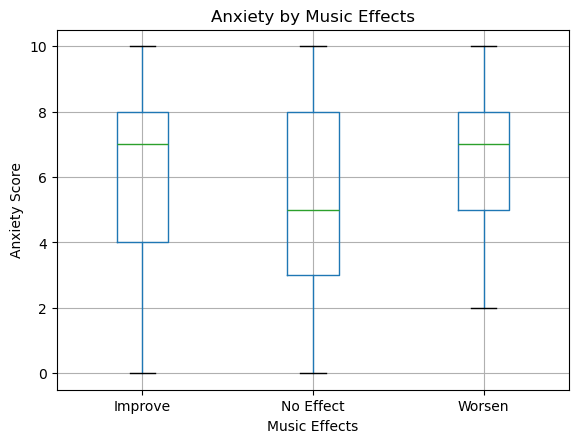

In [13]:
import matplotlib.pyplot as plt
# Anxiety by music effects
plt.figure()
df_clean.boxplot(column='Anxiety', by='Music effects')
plt.title('Anxiety by Music Effects')
plt.suptitle('')
plt.xlabel('Music Effects')
plt.ylabel('Anxiety Score')
plt.show()


<Figure size 640x480 with 0 Axes>

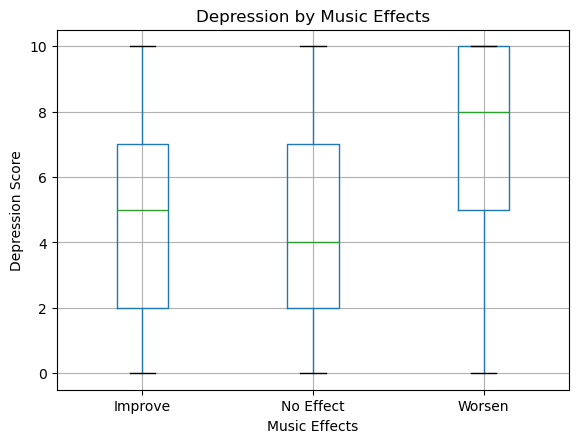

In [14]:
# Depression by music effects
plt.figure()
df_clean.boxplot(column='Depression', by='Music effects')
plt.title('Depression by Music Effects')
plt.suptitle('')
plt.xlabel('Music Effects')
plt.ylabel('Depression Score')
plt.show()


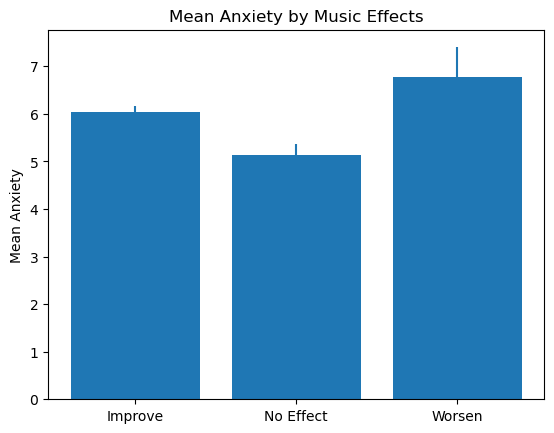

In [15]:
import numpy as np

grouped = df_clean.groupby('Music effects')['Anxiety']
means = grouped.mean()
se = grouped.std() / np.sqrt(grouped.count())

plt.figure()
plt.bar(means.index, means.values)
plt.errorbar(means.index, means.values, yerr=se.values, fmt='none')
plt.title('Mean Anxiety by Music Effects')
plt.ylabel('Mean Anxiety')
plt.show()


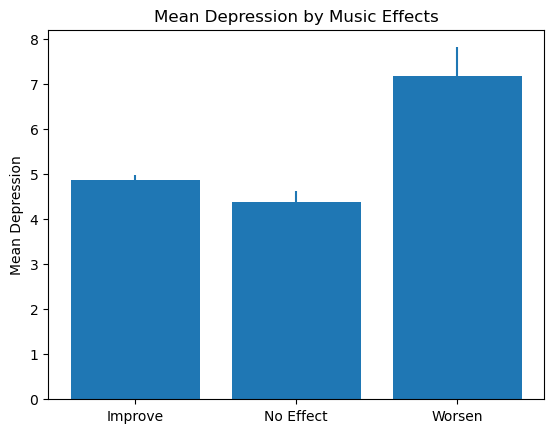

In [16]:
grouped2 = df_clean.groupby('Music effects')['Depression']
means2 = grouped2.mean()
se2 = grouped2.std() / np.sqrt(grouped2.count())

plt.figure()
plt.bar(means2.index, means2.values)
plt.errorbar(means2.index, means2.values, yerr=se.values, fmt='none')
plt.title('Mean Depression by Music Effects')
plt.ylabel('Mean Depression')
plt.show()


In [17]:
import statsmodels.formula.api as smf

df_clean['Improve_dummy'] = (df_clean['Music effects'] == 'Improve').astype(int)

model = smf.ols('Anxiety ~ Improve_dummy', data=df_clean).fit()
print(model.summary())
# here's the logic of using this statistical test: 
#If coefficient on Improve_dummy > 0 and significant → strong evidence.

                            OLS Regression Results                            
Dep. Variable:                Anxiety   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     10.79
Date:                Wed, 25 Feb 2026   Prob (F-statistic):            0.00107
Time:                        19:43:35   Log-Likelihood:                -1773.4
No. Observations:                 728   AIC:                             3551.
Df Residuals:                     726   BIC:                             3560.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.2742      0.203     25.978

In [18]:
df_clean['Improve_dummy'] = (df_clean['Music effects'] == 'Improve').astype(int)

model = smf.ols('Anxiety ~ Improve_dummy', data=df_clean).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                Anxiety   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     10.79
Date:                Wed, 25 Feb 2026   Prob (F-statistic):            0.00107
Time:                        19:43:35   Log-Likelihood:                -1773.4
No. Observations:                 728   AIC:                             3551.
Df Residuals:                     726   BIC:                             3560.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.2742      0.203     25.978

In [19]:
# Check missing values
df_hours = df_clean.dropna(subset=['Hours per day', 'Music effects'])

In [20]:
# make sure everything is numeric
df_hours['Hours per day'] = pd.to_numeric(df_hours['Hours per day'], errors='coerce')
df_hours = df_hours.dropna(subset=['Hours per day'])

In [21]:
# check if weird number shows up
print(df_hours['Hours per day'].describe())

count    728.000000
mean       3.591415
std        3.038554
min        0.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       24.000000
Name: Hours per day, dtype: float64


In [22]:
# does listening time differ by music type?
df_hours.groupby('Music effects')['Hours per day'].mean()

Music effects
Improve      3.662731
No Effect    3.445858
Worsen       2.764706
Name: Hours per day, dtype: float64

here, we do see that people who claim music improves their mental health does high the highest listening time (3.66) compared to only 2.8 listening hours in the group who claims music worsens their mental health.

<Figure size 640x480 with 0 Axes>

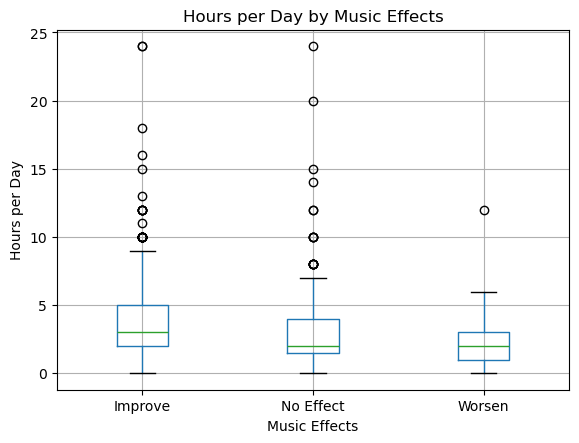

In [23]:
# hours per day by music effects
plt.figure()
df_hours.boxplot(column='Hours per day', by='Music effects')
plt.title('Hours per Day by Music Effects')
plt.suptitle('')
plt.xlabel('Music Effects')
plt.ylabel('Hours per Day')
plt.show()

In [24]:
df_hours['Improve_dummy'] = (df_hours['Music effects'] == 'Improve').astype(int)

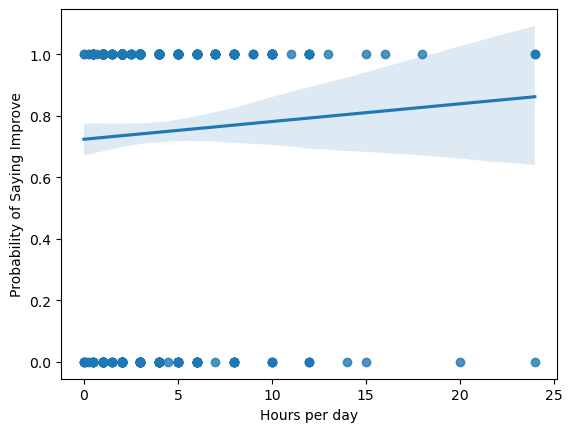

In [25]:
import seaborn as sns

sns.regplot(x='Hours per day', y='Improve_dummy', data=df_hours, logistic=False)
plt.ylabel('Probability of Saying Improve')
plt.show()

In [26]:
df_hours['Hour_bin'] = pd.cut(df_hours['Hours per day'],
                               bins=[0,1,3,5,10,24],
                               labels=['0-1','1-3','3-5','5-10','10+'])

df_hours.groupby('Hour_bin')['Improve_dummy'].mean()

/tmp/ipykernel_151/4222777410.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hours.groupby('Hour_bin')['Improve_dummy'].mean()


Hour_bin
0-1     0.685714
1-3     0.735484
3-5     0.826087
5-10    0.780702
10+     0.650000
Name: Improve_dummy, dtype: float64

/tmp/ipykernel_151/2931091878.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hours.groupby('Hour_bin')['Improve_dummy'].mean().plot(kind='bar')


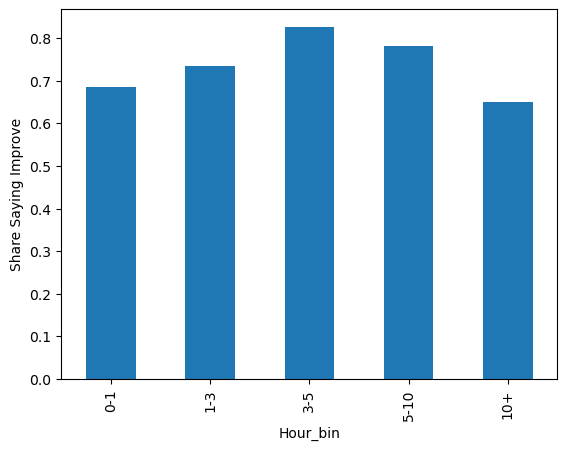

In [28]:
df_hours.groupby('Hour_bin')['Improve_dummy'].mean().plot(kind='bar')
plt.ylabel('Share Saying Improve')
plt.show()

In [29]:
df_hours['Hours_squared'] = df_hours['Hours per day'] ** 2

In [30]:
import statsmodels.formula.api as smf

model = smf.ols('Improve_dummy ~ Q("Hours per day") + Hours_squared', data=df_hours).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Improve_dummy   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     3.591
Date:                Wed, 25 Feb 2026   Prob (F-statistic):             0.0281
Time:                        19:56:16   Log-Likelihood:                -425.31
No. Observations:                 728   AIC:                             856.6
Df Residuals:                     725   BIC:                             870.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.6693      0

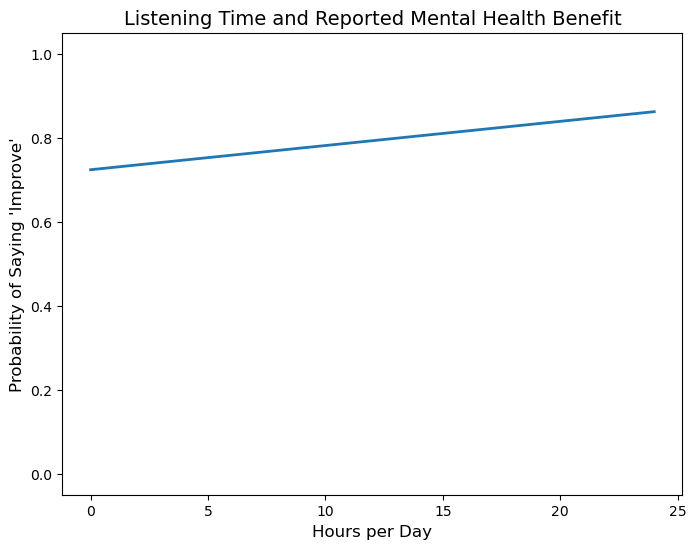

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Make sure Improve_dummy exists
df_hours['Improve_dummy'] = (df_hours['Music effects'] == 'Improve').astype(int)

# X and Y
x = df_hours['Hours per day']
y = df_hours['Improve_dummy']


coef = np.polyfit(x, y, 1)
poly_fn = np.poly1d(coef)


x_sorted = np.sort(x)

# Create plot
plt.figure(figsize=(8,6))


plt.plot(x_sorted, poly_fn(x_sorted), linewidth=2)

plt.xlabel("Hours per Day", fontsize=12)
plt.ylabel("Probability of Saying 'Improve'", fontsize=12)
plt.title("Listening Time and Reported Mental Health Benefit", fontsize=14)

plt.ylim(-0.05, 1.05)

plt.show()

/tmp/ipykernel_151/1863540860.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = df_hours.groupby('Hour_bin')['Improve_dummy'].mean()


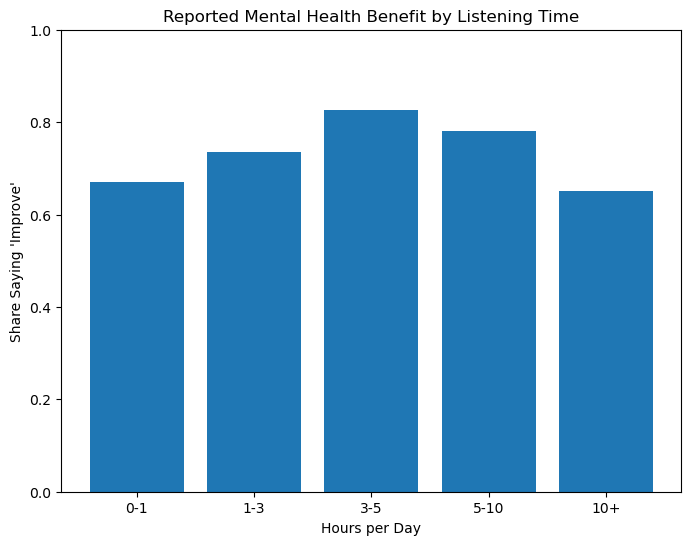

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure Improve dummy exists
df_hours['Improve_dummy'] = (df_hours['Music effects'] == 'Improve').astype(int)

# Create bins
df_hours['Hour_bin'] = pd.cut(
    df_hours['Hours per day'],
    bins=[0, 1, 3, 5, 10, 24],
    labels=['0-1', '1-3', '3-5', '5-10', '10+'],
    include_lowest=True
)

# Calculate share saying Improve in each bin
bin_means = df_hours.groupby('Hour_bin')['Improve_dummy'].mean()

# Plot
plt.figure(figsize=(8,6))
plt.bar(bin_means.index.astype(str), bin_means.values)

plt.xlabel("Hours per Day")
plt.ylabel("Share Saying 'Improve'")
plt.title("Reported Mental Health Benefit by Listening Time")
plt.ylim(0, 1)

plt.show()
